# Model performance by ERA5 weather condition

This notebook compares interpolation, U-Net, and Transformer performance during JJA 2022-2025, stratified by weather conditions from the downloaded ERA5 files: precipitation, wind gust, low cloud cover, and total cloud cover. It also keeps temperature and dew point regimes from the existing test/extra files.

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "figure.dpi": 130,
})

fig_dir = Path("../figures/weather_condition_compare_era5")
fig_dir.mkdir(parents=True, exist_ok=True)

test_path = "../.data/downscaling_splits/test_norm.nc"
extra_path = "../.data/downscaling_splits_extra/test_extra_norm.nc"
unet_path = "../outputs/test_predictions.nc"
transformer_path = "../outputs/test_predictions_transformer_t_elev_oscar.nc"
weather_dir = Path("../.data/ERA5_weather_conditions")
weather_extract_dir = Path("../.data/ERA5_weather_conditions_extracted")

ds_test = xr.open_dataset(test_path)
ds_extra = xr.open_dataset(extra_path)
ds_unet = xr.open_dataset(unet_path)
ds_tf = xr.open_dataset(transformer_path)

In [2]:
pred_var = "pred_tmax_highres"
truth_var = "tmax_highres"
interp_var = "tmax_lowres_interp"
mask_var = "valid_mask"

common_time = np.intersect1d(ds_unet["time"].values, ds_tf["time"].values)
common_time = np.intersect1d(common_time, ds_test["time"].values)
common_time = np.intersect1d(common_time, ds_extra["time"].values)

truth = ds_test[truth_var].sel(time=common_time)
interp = ds_test[interp_var].sel(time=common_time)
unet = ds_unet[pred_var].sel(time=common_time)
tf = ds_tf[pred_var].sel(time=common_time)
mask = ds_test[mask_var].astype(bool)

d2m = ds_extra["d2m_lowres_interp"].sel(time=common_time)

def kelvin_to_celsius_if_needed(da):
    vals = da.where(mask).values if {"lat", "lon"}.issubset(da.dims) else da.values
    return da - 273.15 if float(np.nanmean(vals)) > 100 else da

truth = kelvin_to_celsius_if_needed(truth)
interp = kelvin_to_celsius_if_needed(interp)
unet = kelvin_to_celsius_if_needed(unet)
tf = kelvin_to_celsius_if_needed(tf)
d2m = kelvin_to_celsius_if_needed(d2m)

models = {
    "Interpolation": interp,
    "U-Net T+Elev": unet,
    "Transformer T+Elev": tf,
}

print("Common test period:", pd.to_datetime(common_time[0]).date(), "to", pd.to_datetime(common_time[-1]).date())
print("Number of days:", len(common_time))

Common test period: 2022-06-01 to 2025-08-31
Number of days: 368


In [3]:
def daily_masked_mean(da, mask):
    return np.nanmean(da.where(mask).values, axis=(1, 2))

def daily_rmse(pred, truth, mask):
    return np.sqrt(daily_masked_mean((pred - truth) ** 2, mask))

def daily_mae(pred, truth, mask):
    return daily_masked_mean(np.abs(pred - truth), mask)

def daily_bias(pred, truth, mask):
    return daily_masked_mean(pred - truth, mask)

def daily_spatial_corr(pred, truth, mask):
    mask2d = mask.values.astype(bool)
    out = []
    for i in range(truth.sizes["time"]):
        x = pred.isel(time=i).values
        y = truth.isel(time=i).values
        valid = mask2d & np.isfinite(x) & np.isfinite(y)
        if valid.sum() < 2 or np.std(x[valid]) == 0 or np.std(y[valid]) == 0:
            out.append(np.nan)
        else:
            out.append(np.corrcoef(x[valid], y[valid])[0, 1])
    return np.array(out)

def domain_mean_highres(da, mask):
    return np.nanmean(da.where(mask).values, axis=(1, 2))

daily = pd.DataFrame(index=pd.to_datetime(common_time))

for name, pred in models.items():
    daily[f"{name} RMSE"] = daily_rmse(pred, truth, mask)
    daily[f"{name} MAE"] = daily_mae(pred, truth, mask)
    daily[f"{name} Bias"] = daily_bias(pred, truth, mask)
    daily[f"{name} Spatial corr"] = daily_spatial_corr(pred, truth, mask)

daily["Truth Tmax mean (deg C)"] = domain_mean_highres(truth, mask)
daily["Dew point mean (deg C)"] = domain_mean_highres(d2m, mask)
daily["U-Net minus Transformer RMSE"] = daily["U-Net T+Elev RMSE"] - daily["Transformer T+Elev RMSE"]
daily["Transformer beats U-Net"] = daily["Transformer T+Elev RMSE"] < daily["U-Net T+Elev RMSE"]
daily["U-Net beats interpolation"] = daily["U-Net T+Elev RMSE"] < daily["Interpolation RMSE"]
daily["Transformer beats interpolation"] = daily["Transformer T+Elev RMSE"] < daily["Interpolation RMSE"]

daily.head()

,Interpolation RMSE,Interpolation MAE,Interpolation Bias,Interpolation Spatial corr,U-Net T+Elev RMSE,U-Net T+Elev MAE,U-Net T+Elev Bias,U-Net T+Elev Spatial corr,Transformer T+Elev RMSE,Transformer T+Elev MAE,Transformer T+Elev Bias,Transformer T+Elev Spatial corr,Truth Tmax mean (deg C),Dew point mean (deg C),U-Net minus Transformer RMSE,Transformer beats U-Net,U-Net beats interpolation,Transformer beats interpolation
2022-06-01,1.974516,1.570240,-0.802886,0.959668,1.854987,1.484120,-0.125186,0.959339,1.949048,1.598804,-0.214370,0.958298,24.254023,14.048169,-0.094061,False,True,True
2022-06-02,1.815732,1.392966,-1.002048,0.946260,1.114243,0.877365,-0.318328,0.971136,1.091479,0.854025,-0.353829,0.970387,24.257856,14.729773,0.022764,True,True,True
2022-06-03,1.660647,1.358530,-0.723761,0.907457,1.436130,1.105063,-0.024839,0.912903,1.348085,1.042498,-0.085355,0.923482,22.414560,11.686384,0.088045,True,True,True
2022-06-04,1.554300,1.199718,-0.676227,0.928666,0.971134,0.773734,-0.033606,0.964228,0.970089,0.771103,-0.062163,0.963872,23.392042,8.827355,0.001045,True,True,True
2022-06-05,1.599296,1.266139,-0.865474,0.910486,1.090893,0.863493,-0.220053,0.951932,0.948994,0.748003,-0.276567,0.955973,22.831129,6.657612,0.141899,True,True,True


In [4]:
def standardize_time(ds):
    if "valid_time" in ds.coords:
        ds = ds.rename({"valid_time": "time"})
    if "latitude" in ds.coords:
        ds = ds.rename({"latitude": "lat", "longitude": "lon"})
    return ds

def open_many(paths):
    datasets = [standardize_time(xr.open_dataset(p)) for p in sorted(paths)]
    return xr.concat(datasets, dim="time").sortby("time")

def domain_mean_coarse(da):
    arr = da.values
    return pd.Series(np.nanmean(arr, axis=(1, 2)), index=pd.to_datetime(da["time"].values))

gust_ds = open_many(weather_dir.glob("era5_gust_dailymax_*.nc"))
precip_ds = open_many(weather_dir.glob("era5_precip_dailysum_*.nc"))
lcc_ds = open_many(weather_extract_dir.glob("era5_cloud_dailymean_*/low_cloud_cover*.nc"))
tcc_ds = open_many(weather_extract_dir.glob("era5_cloud_dailymean_*/total_cloud_cover*.nc"))

weather_daily = pd.DataFrame(index=pd.to_datetime(common_time))
weather_daily["Precip mean (mm day-1)"] = domain_mean_coarse(precip_ds["tp"] * 1000).reindex(weather_daily.index)
weather_daily["Gust max mean (m s-1)"] = domain_mean_coarse(gust_ds["fg10"]).reindex(weather_daily.index)
weather_daily["Low cloud cover mean (%)"] = domain_mean_coarse(lcc_ds["lcc"] * 100).reindex(weather_daily.index)
weather_daily["Total cloud cover mean (%)"] = domain_mean_coarse(tcc_ds["tcc"] * 100).reindex(weather_daily.index)

daily = daily.join(weather_daily)

print(weather_daily.describe())
daily.head()

       Precip mean (mm day-1)  Gust max mean (m s-1)  \
count              368.000000             368.000000   
mean                 3.847519              10.606806   
std                  2.557736               1.887284   
min                  0.039392               6.135136   
25%                  2.044966               9.221376   
50%                  3.432999              10.229665   
75%                  5.189499              11.794115   
max                 16.271580              18.514412   

       Low cloud cover mean (%)  Total cloud cover mean (%)  
count                368.000000                  368.000000  
mean                  24.752787                   58.511799  
std                   10.876472                   13.202934  
min                    4.536483                   23.205944  
25%                   15.588936                   49.564054  
50%                   25.098038                   58.987871  
75%                   32.402874                   68.158400  

,Interpolation RMSE,Interpolation MAE,Interpolation Bias,Interpolation Spatial corr,U-Net T+Elev RMSE,U-Net T+Elev MAE,U-Net T+Elev Bias,U-Net T+Elev Spatial corr,Transformer T+Elev RMSE,Transformer T+Elev MAE,...,Truth Tmax mean (deg C),Dew point mean (deg C),U-Net minus Transformer RMSE,Transformer beats U-Net,U-Net beats interpolation,Transformer beats interpolation,Precip mean (mm day-1),Gust max mean (m s-1),Low cloud cover mean (%),Total cloud cover mean (%)
2022-06-01,1.974516,1.570240,-0.802886,0.959668,1.854987,1.484120,-0.125186,0.959339,1.949048,1.598804,...,24.254023,14.048169,-0.094061,False,True,True,2.538937,10.917319,22.744184,68.203194
2022-06-02,1.815732,1.392966,-1.002048,0.946260,1.114243,0.877365,-0.318328,0.971136,1.091479,0.854025,...,24.257856,14.729773,0.022764,True,True,True,2.452543,8.997869,30.737305,73.894363
2022-06-03,1.660647,1.358530,-0.723761,0.907457,1.436130,1.105063,-0.024839,0.912903,1.348085,1.042498,...,22.414560,11.686384,0.088045,True,True,True,3.630273,9.493819,31.457260,68.961746
2022-06-04,1.554300,1.199718,-0.676227,0.928666,0.971134,0.773734,-0.033606,0.964228,0.970089,0.771103,...,23.392042,8.827355,0.001045,True,True,True,1.365885,9.799119,30.139236,52.759449
2022-06-05,1.599296,1.266139,-0.865474,0.910486,1.090893,0.863493,-0.220053,0.951932,0.948994,0.748003,...,22.831129,6.657612,0.141899,True,True,True,0.852510,9.144770,13.294134,44.167362


In [14]:
def tercile_labels(series, low_name, mid_name, high_name):
    q1, q2 = series.quantile([1 / 3, 2 / 3])
    return pd.cut(series, [-np.inf, q1, q2, np.inf], labels=[low_name, mid_name, high_name], include_lowest=True)

daily["Temperature regime"] = tercile_labels(daily["Truth Tmax mean (deg C)"], "Cool", "Moderate", "Hot")
daily["Humidity regime"] = tercile_labels(daily["Dew point mean (deg C)"], "Dry", "Moderate humidity", "Humid")
daily["Rain regime"] = tercile_labels(daily["Precip mean (mm day-1)"], "Dry", "Moderate rain", "Wet")
daily["Wind regime"] = tercile_labels(daily["Gust max mean (m s-1)"], "Calm", "Moderate wind", "Windy")
daily["Cloud regime"] = tercile_labels(daily["Total cloud cover mean (%)"], "Clear", "Partly cloudy", "Cloudy")
daily["Low-cloud regime"] = tercile_labels(
    daily["Low cloud cover mean (%)"],
    "Low low-cloud",
    "Moderate low-cloud",
    "High low-cloud"
)
# Threshold flags are useful for intuitive case selection. Domain-mean thresholds are conservative.
daily["Rainy day"] = daily["Precip mean (mm day-1)"] >= 1.0
daily["Very wet day"] = daily["Precip mean (mm day-1)"] >= daily["Precip mean (mm day-1)"].quantile(0.9)
daily["Very windy day"] = daily["Gust max mean (m s-1)"] >= daily["Gust max mean (m s-1)"].quantile(0.9)
daily["Very cloudy day"] = daily["Total cloud cover mean (%)"] >= daily["Total cloud cover mean (%)"].quantile(0.9)
daily["Hot and wet"] = daily["Temperature regime"].eq("Hot") & daily["Rain regime"].eq("Wet")
daily["Hot and cloudy"] = daily["Temperature regime"].eq("Hot") & daily["Cloud regime"].eq("Cloudy")
daily["Hot and humid"] = daily["Temperature regime"].eq("Hot") & daily["Humidity regime"].eq("Humid")

for col in ["Temperature regime", "Humidity regime", "Rain regime", "Wind regime", "Cloud regime", "Low-cloud regime"]:
    print("\n", col)
    print(daily[col].value_counts(dropna=False))


 Temperature regime
Temperature regime
Cool        123
Hot         123
Moderate    122
Name: count, dtype: int64

 Humidity regime
Humidity regime
Dry                  123
Humid                123
Moderate humidity    122
Name: count, dtype: int64

 Rain regime
Rain regime
Dry              123
Wet              123
Moderate rain    122
Name: count, dtype: int64

 Wind regime
Wind regime
Calm             123
Windy            123
Moderate wind    122
Name: count, dtype: int64

 Cloud regime
Cloud regime
Clear            123
Cloudy           123
Partly cloudy    122
Name: count, dtype: int64

 Low-cloud regime
Low-cloud regime
Low low-cloud         123
High low-cloud        123
Moderate low-cloud    122
Name: count, dtype: int64


In [15]:
metric_cols = [
    "Interpolation RMSE", "U-Net T+Elev RMSE", "Transformer T+Elev RMSE",
    "Interpolation MAE", "U-Net T+Elev MAE", "Transformer T+Elev MAE",
    "Interpolation Spatial corr", "U-Net T+Elev Spatial corr", "Transformer T+Elev Spatial corr",
]

def summarize_by_condition(condition_col):
    grouped = daily.groupby(condition_col, observed=True)
    summary = grouped[metric_cols].mean()
    summary["n days"] = grouped.size()
    summary["Transformer RMSE improvement vs U-Net"] = summary["U-Net T+Elev RMSE"] - summary["Transformer T+Elev RMSE"]
    summary["U-Net RMSE improvement vs interpolation"] = summary["Interpolation RMSE"] - summary["U-Net T+Elev RMSE"]
    summary["Transformer RMSE improvement vs interpolation"] = summary["Interpolation RMSE"] - summary["Transformer T+Elev RMSE"]
    summary["Transformer beats U-Net (%)"] = grouped["Transformer beats U-Net"].mean() * 100
    summary["U-Net worse than interpolation (%)"] = grouped["U-Net beats interpolation"].apply(lambda x: (~x).mean() * 100)
    summary["Transformer worse than interpolation (%)"] = grouped["Transformer beats interpolation"].apply(lambda x: (~x).mean() * 100)
    return summary

summaries = {
    "temperature": summarize_by_condition("Temperature regime"),
    "humidity": summarize_by_condition("Humidity regime"),
    "rain": summarize_by_condition("Rain regime"),
    "wind": summarize_by_condition("Wind regime"),
    "cloud": summarize_by_condition("Cloud regime"),
    "low_cloud": summarize_by_condition("Low-cloud regime"),
}

display(summaries["rain"])
display(summaries["wind"])
display(summaries["cloud"])

,Interpolation RMSE,U-Net T+Elev RMSE,Transformer T+Elev RMSE,Interpolation MAE,U-Net T+Elev MAE,Transformer T+Elev MAE,Interpolation Spatial corr,U-Net T+Elev Spatial corr,Transformer T+Elev Spatial corr,n days,Transformer RMSE improvement vs U-Net,U-Net RMSE improvement vs interpolation,Transformer RMSE improvement vs interpolation,Transformer beats U-Net (%),U-Net worse than interpolation (%),Transformer worse than interpolation (%)
Rain regime,,,,,,,,,,,,,,,,
Dry,1.584736,1.112206,1.079162,1.202102,0.890181,0.859142,0.819483,0.903746,0.907707,123,0.033044,0.472529,0.505573,69.918699,3.252033,3.252033
Moderate rain,1.551500,1.122603,1.103414,1.197941,0.895980,0.879077,0.842952,0.912817,0.915122,122,0.019189,0.428897,0.448085,56.557377,1.639344,0.819672
Wet,1.521226,1.169085,1.162605,1.180265,0.920915,0.913849,0.880570,0.927810,0.928254,123,0.006480,0.352142,0.358621,56.910569,7.317073,8.130081


,Interpolation RMSE,U-Net T+Elev RMSE,Transformer T+Elev RMSE,Interpolation MAE,U-Net T+Elev MAE,Transformer T+Elev MAE,Interpolation Spatial corr,U-Net T+Elev Spatial corr,Transformer T+Elev Spatial corr,n days,Transformer RMSE improvement vs U-Net,U-Net RMSE improvement vs interpolation,Transformer RMSE improvement vs interpolation,Transformer beats U-Net (%),U-Net worse than interpolation (%),Transformer worse than interpolation (%)
Wind regime,,,,,,,,,,,,,,,,
Calm,1.601156,1.148818,1.117689,1.232690,0.920746,0.892864,0.816284,0.896320,0.901694,123,0.031129,0.452338,0.483467,65.853659,1.626016,0.813008
Moderate wind,1.553488,1.118488,1.100156,1.191516,0.888729,0.870858,0.846360,0.916125,0.917319,122,0.018332,0.435000,0.453332,61.475410,4.098361,4.098361
Windy,1.502834,1.136554,1.127310,1.156049,0.897542,0.888279,0.880388,0.931955,0.932087,123,0.009244,0.366280,0.375524,56.097561,6.504065,7.317073


,Interpolation RMSE,U-Net T+Elev RMSE,Transformer T+Elev RMSE,Interpolation MAE,U-Net T+Elev MAE,Transformer T+Elev MAE,Interpolation Spatial corr,U-Net T+Elev Spatial corr,Transformer T+Elev Spatial corr,n days,Transformer RMSE improvement vs U-Net,U-Net RMSE improvement vs interpolation,Transformer RMSE improvement vs interpolation,Transformer beats U-Net (%),U-Net worse than interpolation (%),Transformer worse than interpolation (%)
Cloud regime,,,,,,,,,,,,,,,,
Clear,1.518054,1.049372,1.016594,1.155377,0.838105,0.807938,0.821445,0.908173,0.911580,123,0.032778,0.468682,0.501460,66.666667,2.439024,1.626016
Partly cloudy,1.568100,1.148796,1.129951,1.204299,0.914229,0.896518,0.846845,0.913876,0.916282,122,0.018845,0.419304,0.438149,59.836066,4.918033,5.737705
Cloudy,1.571442,1.205938,1.198853,1.220683,0.954891,0.947755,0.874746,0.922332,0.923230,123,0.007086,0.365504,0.372589,56.910569,4.878049,4.878049


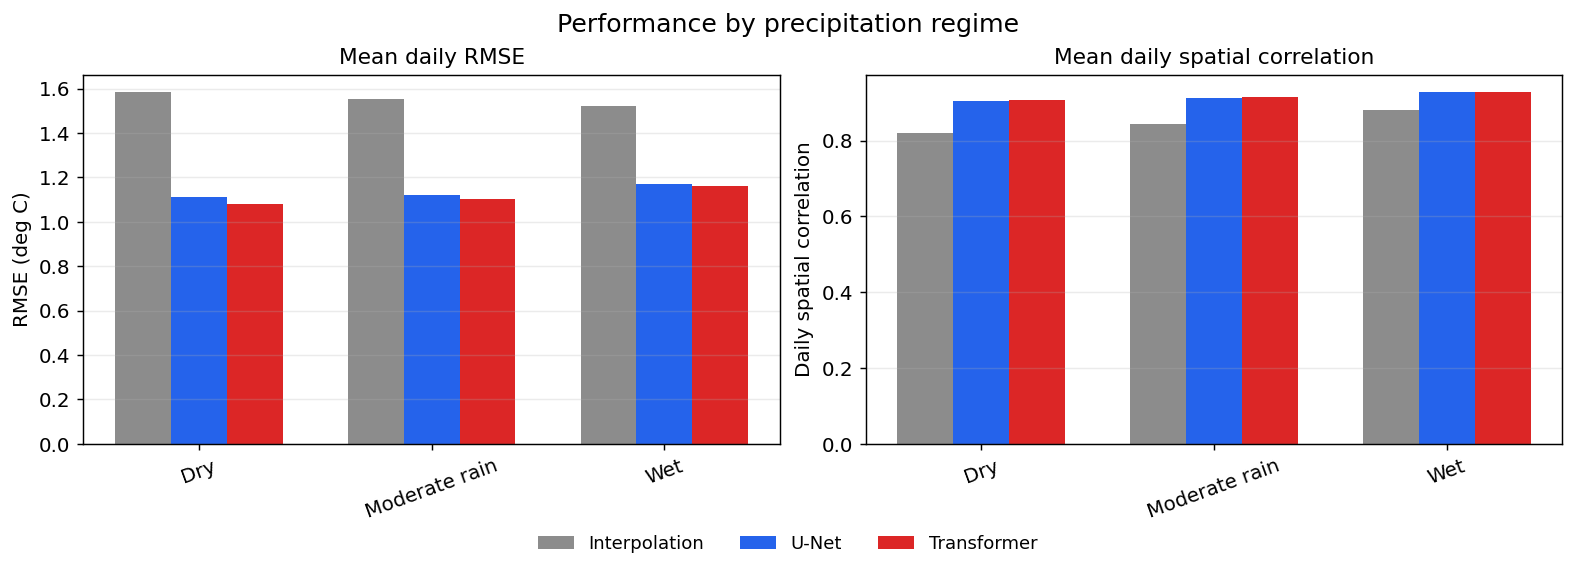

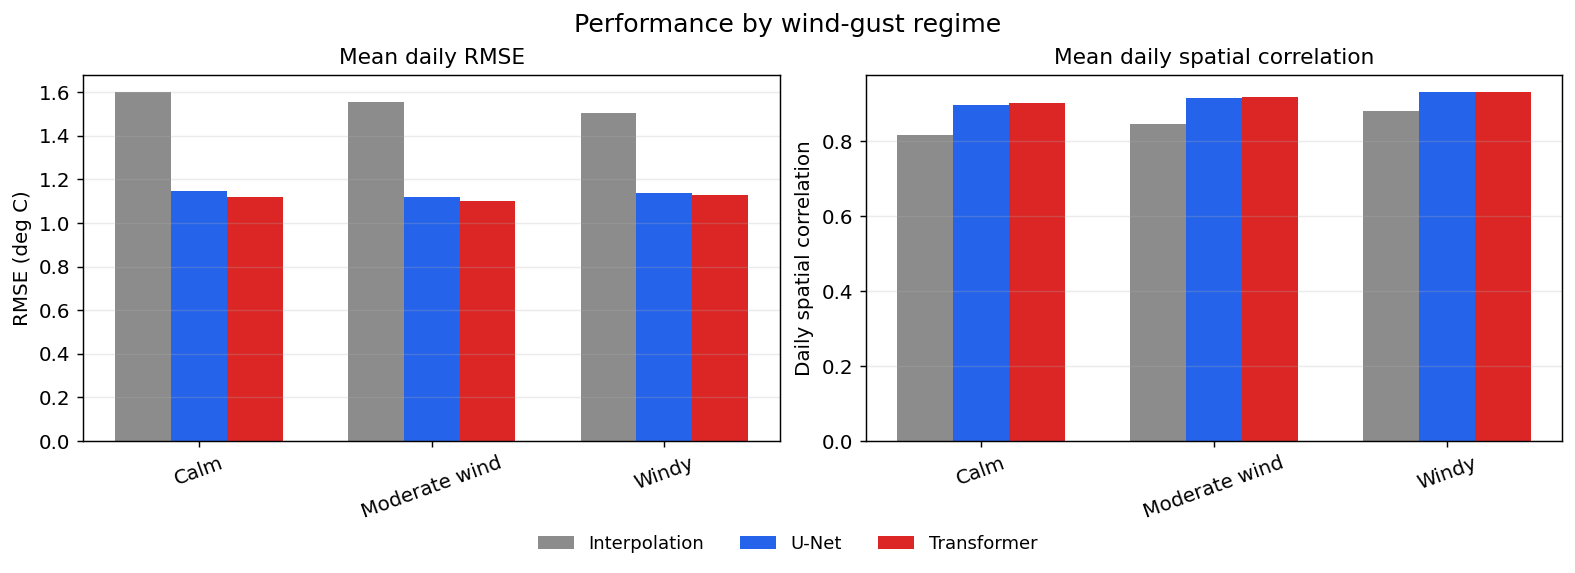

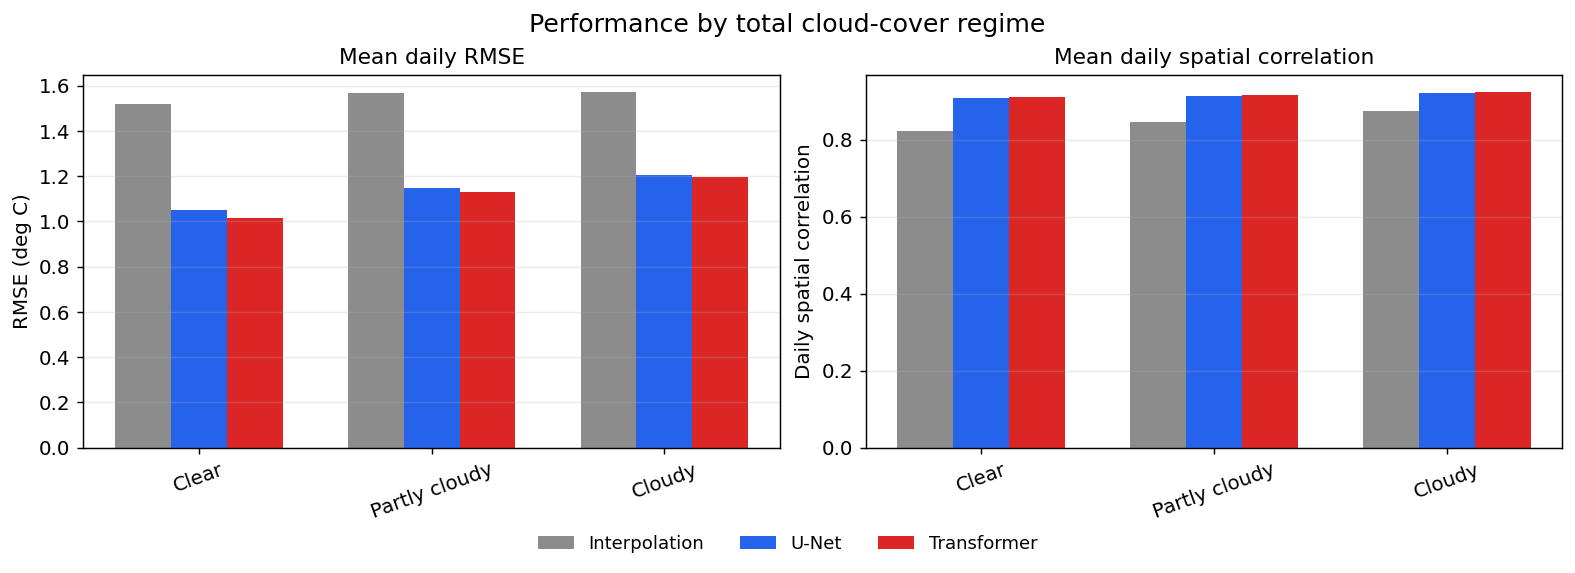

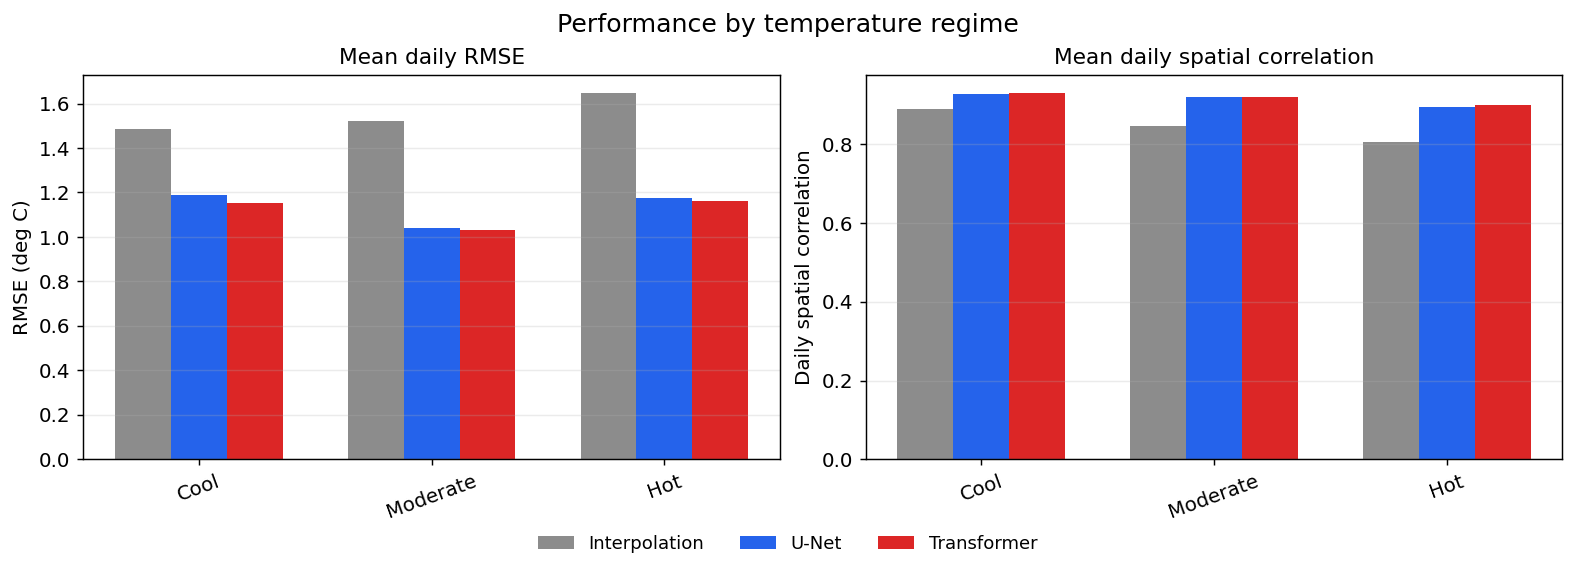

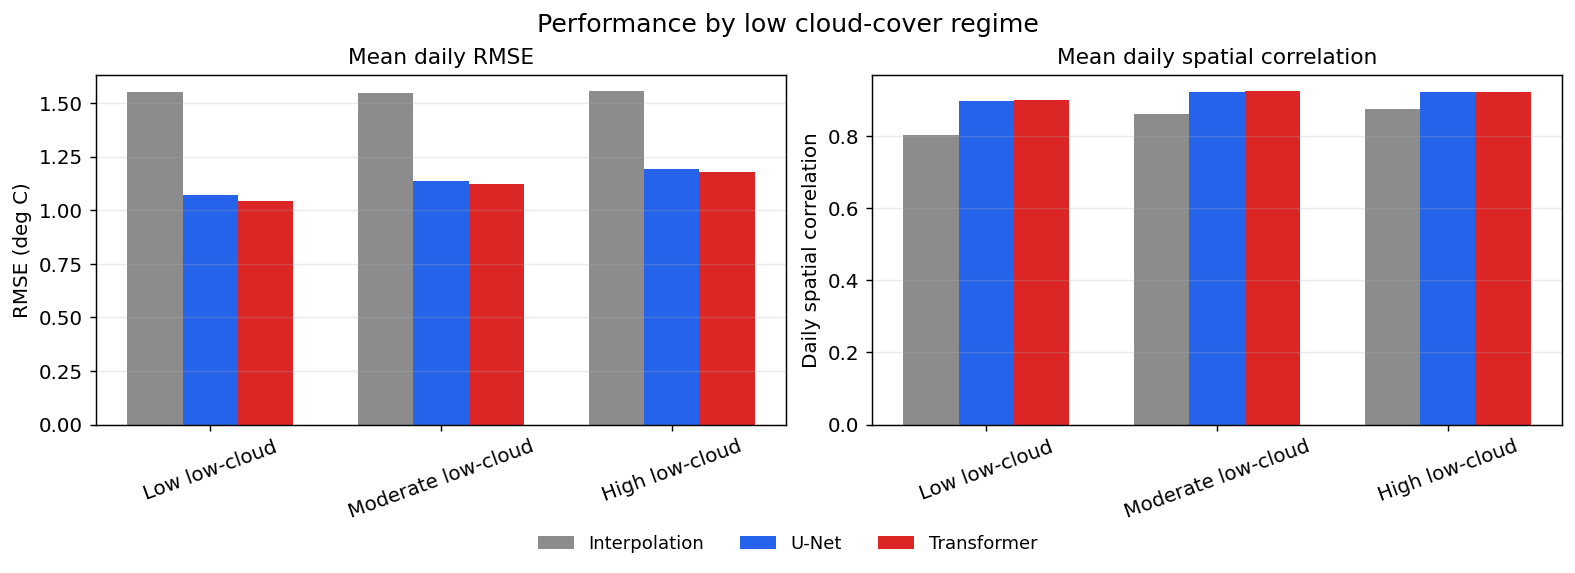

In [16]:
def plot_condition_bars(summary, title, filename):
    rmse_cols = ["Interpolation RMSE", "U-Net T+Elev RMSE", "Transformer T+Elev RMSE"]
    corr_cols = ["Interpolation Spatial corr", "U-Net T+Elev Spatial corr", "Transformer T+Elev Spatial corr"]
    labels = ["Interpolation", "U-Net", "Transformer"]
    colors = ["0.55", "#2563EB", "#DC2626"]
    x = np.arange(len(summary.index))
    width = 0.24

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

    for i, (col, label, color) in enumerate(zip(rmse_cols, labels, colors)):
        axes[0].bar(x + (i - 1) * width, summary[col].values, width, label=label, color=color)

    axes[0].set_xticks(x)
    axes[0].set_xticklabels(summary.index, rotation=20)
    axes[0].set_ylabel("RMSE (deg C)")
    axes[0].set_title("Mean daily RMSE")
    axes[0].grid(axis="y", alpha=0.25)

    for i, (col, label, color) in enumerate(zip(corr_cols, labels, colors)):
        axes[1].bar(x + (i - 1) * width, summary[col].values, width, label=label, color=color)

    axes[1].set_xticks(x)
    axes[1].set_xticklabels(summary.index, rotation=20)
    axes[1].set_ylabel("Daily spatial correlation")
    axes[1].set_title("Mean daily spatial correlation")
    axes[1].grid(axis="y", alpha=0.25)

    handles, legend_labels = axes[1].get_legend_handles_labels()
    fig.legend(
        handles,
        legend_labels,
        loc="lower center",
        ncol=3,
        bbox_to_anchor=(0.5, -0.08),
        frameon=False
    )

    fig.suptitle(title, fontsize=14)

    plt.savefig(fig_dir / filename, bbox_inches="tight", dpi=300)
    plt.show()
plot_condition_bars(summaries["rain"], "Performance by precipitation regime", "performance_by_rain_regime.png")
plot_condition_bars(summaries["wind"], "Performance by wind-gust regime", "performance_by_wind_regime.png")
plot_condition_bars(summaries["cloud"], "Performance by total cloud-cover regime", "performance_by_cloud_regime.png")
plot_condition_bars(summaries["temperature"], "Performance by temperature regime", "performance_by_temperature_regime.png")
plot_condition_bars(
    summaries["low_cloud"],
    "Performance by low cloud-cover regime",
    "performance_by_low_cloud_regime.png"
)


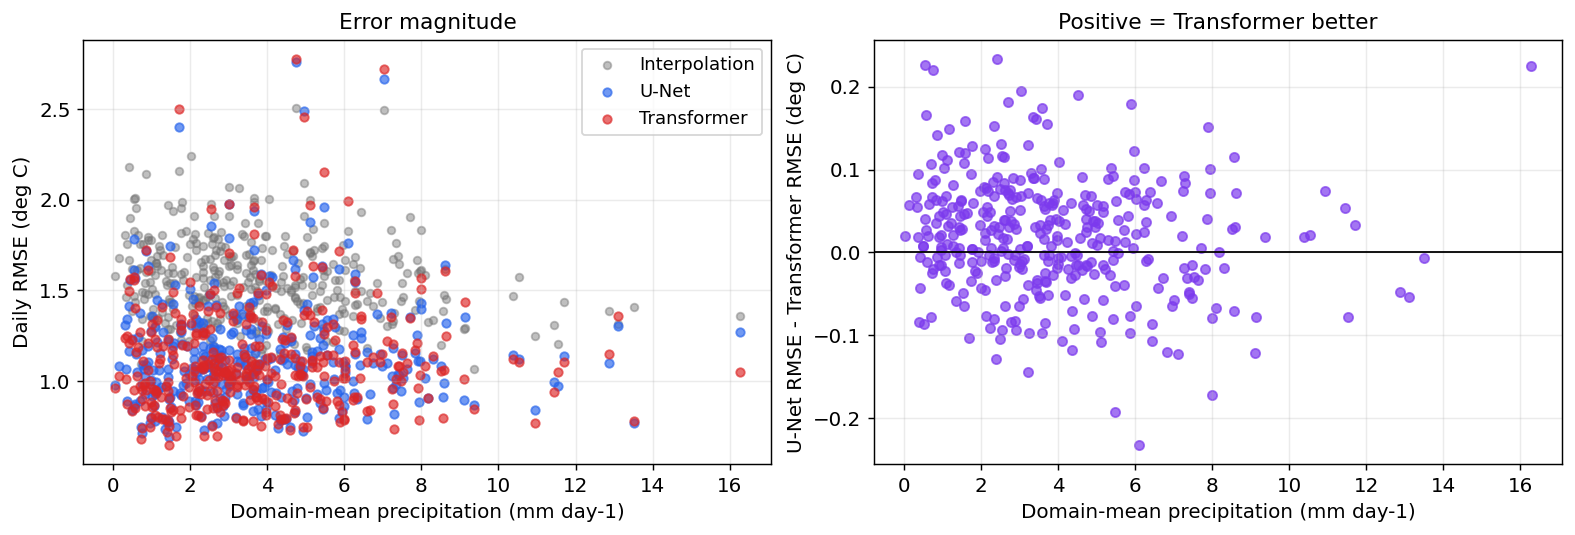

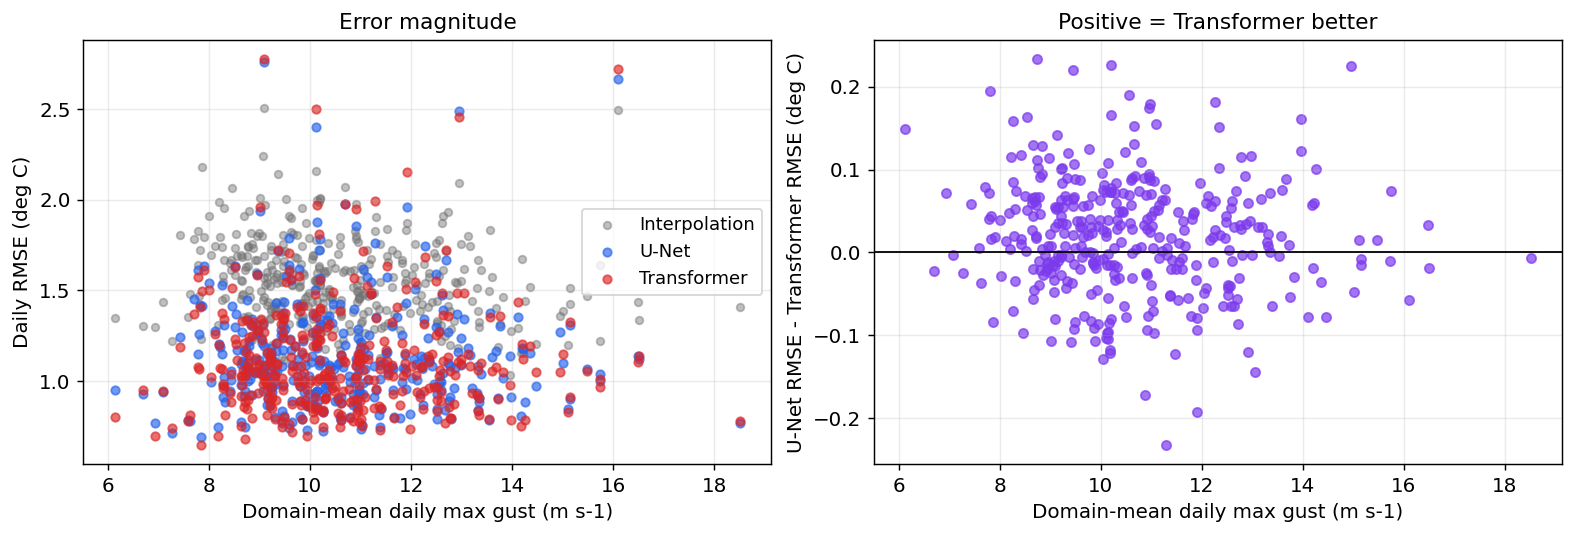

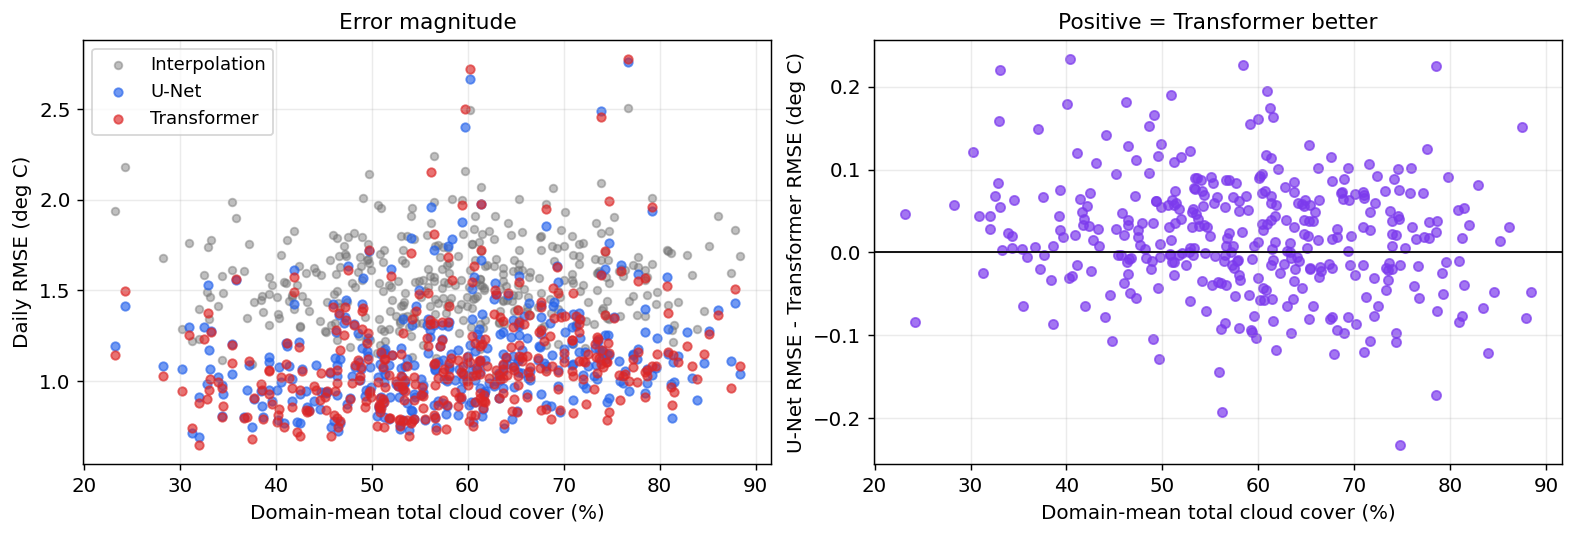

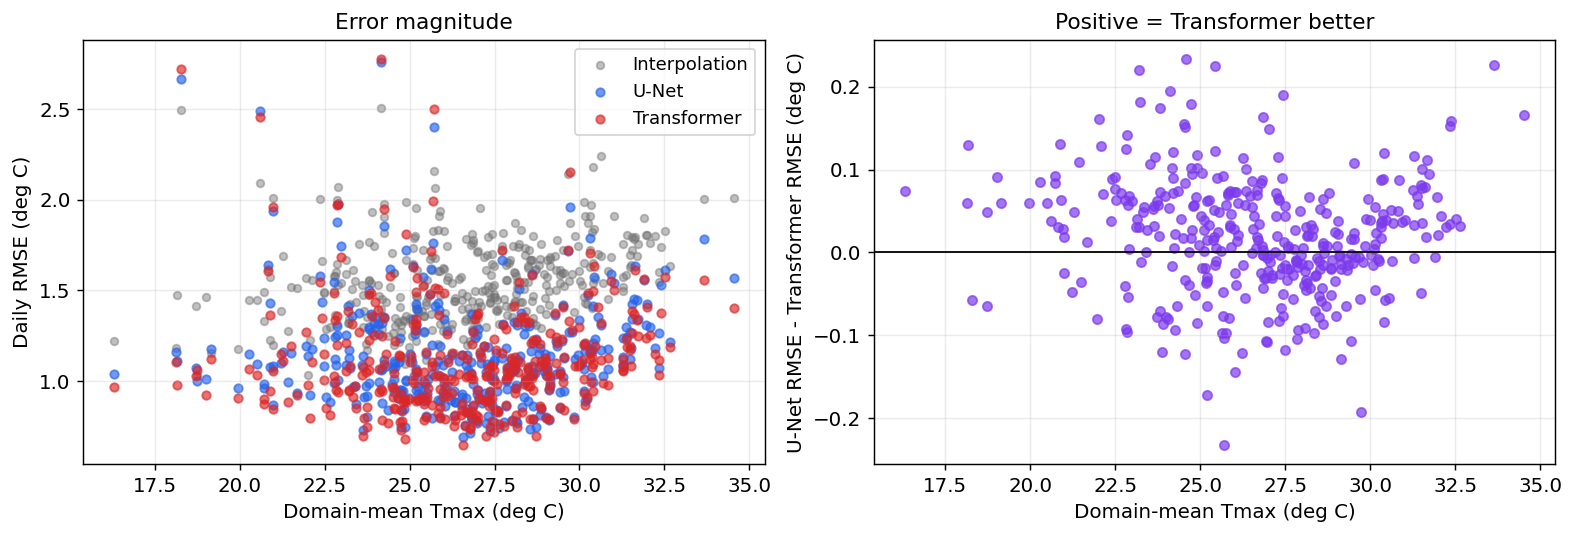

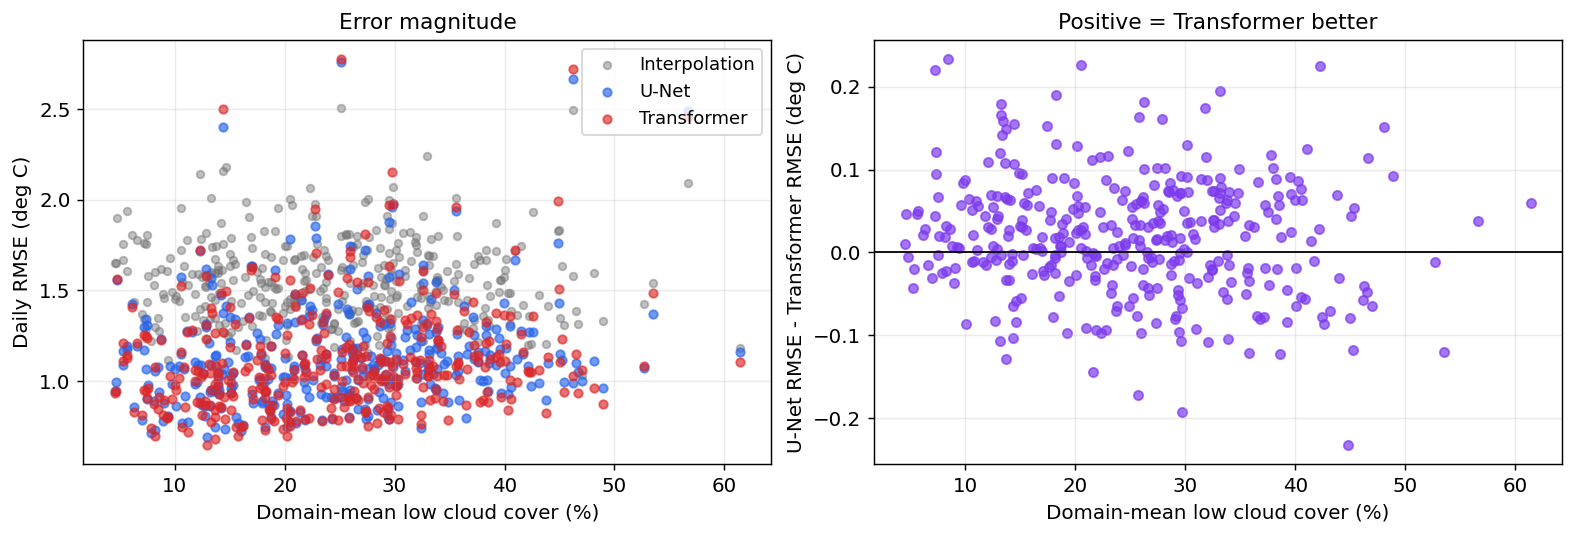

In [20]:
def plot_weather_scatter(xcol, xlabel, filename):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
    axes[0].scatter(daily[xcol], daily["Interpolation RMSE"], s=18, alpha=0.45, label="Interpolation", color="0.45")
    axes[0].scatter(daily[xcol], daily["U-Net T+Elev RMSE"], s=22, alpha=0.65, label="U-Net", color="#2563EB")
    axes[0].scatter(daily[xcol], daily["Transformer T+Elev RMSE"], s=22, alpha=0.65, label="Transformer", color="#DC2626")
    axes[0].set_xlabel(xlabel)
    axes[0].set_ylabel("Daily RMSE (deg C)")
    axes[0].set_title("Error magnitude")
    axes[0].grid(alpha=0.25)
    axes[0].legend()

    axes[1].axhline(0, color="k", linewidth=1)
    axes[1].scatter(daily[xcol], daily["U-Net minus Transformer RMSE"], s=26, alpha=0.7, color="#7C3AED")
    axes[1].set_xlabel(xlabel)
    axes[1].set_ylabel("U-Net RMSE - Transformer RMSE (deg C)")
    axes[1].set_title("Positive = Transformer better")
    axes[1].grid(alpha=0.25)

    plt.savefig(fig_dir / filename, bbox_inches="tight", dpi=300)
    plt.show()

plot_weather_scatter("Precip mean (mm day-1)", "Domain-mean precipitation (mm day-1)", "scatter_rmse_vs_precip.png")
plot_weather_scatter("Gust max mean (m s-1)", "Domain-mean daily max gust (m s-1)", "scatter_rmse_vs_gust.png")
plot_weather_scatter("Total cloud cover mean (%)", "Domain-mean total cloud cover (%)", "scatter_rmse_vs_total_cloud.png")
plot_weather_scatter("Truth Tmax mean (deg C)", "Domain-mean Tmax (deg C)", "scatter_rmse_vs_temperature.png")
plot_weather_scatter(
    "Low cloud cover mean (%)",
    "Domain-mean low cloud cover (%)",
    "scatter_rmse_vs_low_cloud.png"
)


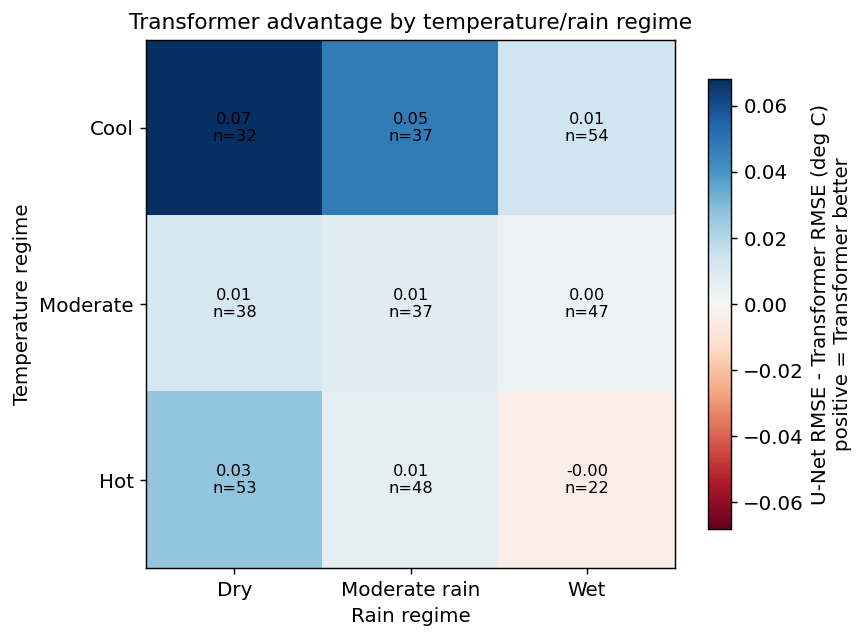

Rain regime,Dry,Moderate rain,Wet
Temperature regime,,,
Cool,0.068003,0.047329,0.013390
Moderate,0.012041,0.008289,0.003736
Hot,0.026995,0.005899,-0.004619


In [18]:
two_way = daily.pivot_table(
    index="Temperature regime",
    columns="Rain regime",
    values="U-Net minus Transformer RMSE",
    aggfunc="mean",
    observed=True,
)
count_two_way = daily.pivot_table(
    index="Temperature regime",
    columns="Rain regime",
    values="U-Net minus Transformer RMSE",
    aggfunc="size",
    observed=True,
)

fig, ax = plt.subplots(figsize=(6.6, 4.8), constrained_layout=True)
vmax = np.nanmax(np.abs(two_way.values))
im = ax.imshow(two_way.values, cmap="RdBu", vmin=-vmax, vmax=vmax)
ax.set_xticks(np.arange(two_way.shape[1]))
ax.set_xticklabels(two_way.columns)
ax.set_yticks(np.arange(two_way.shape[0]))
ax.set_yticklabels(two_way.index)
ax.set_xlabel("Rain regime")
ax.set_ylabel("Temperature regime")
ax.set_title("Transformer advantage by temperature/rain regime")

for i in range(two_way.shape[0]):
    for j in range(two_way.shape[1]):
        val = two_way.values[i, j]
        n = count_two_way.values[i, j]
        if np.isfinite(val):
            ax.text(j, i, f"{val:.2f}\nn={int(n)}", ha="center", va="center", fontsize=9)

cb = plt.colorbar(im, ax=ax, shrink=0.85)
cb.set_label("U-Net RMSE - Transformer RMSE (deg C)\npositive = Transformer better")
plt.savefig(fig_dir / "transformer_advantage_temperature_rain_heatmap.png", bbox_inches="tight", dpi=300)
plt.show()

two_way

In [19]:
conditions = {
    "All days": np.ones(len(daily), dtype=bool),
    "Hot": daily["Temperature regime"].eq("Hot"),
    "Wet": daily["Rain regime"].eq("Wet"),
    "Windy": daily["Wind regime"].eq("Windy"),
    "Cloudy": daily["Cloud regime"].eq("Cloudy"),
    "Rainy day >=1 mm/day": daily["Rainy day"],
    "Very wet top 10%": daily["Very wet day"],
    "Very windy top 10%": daily["Very windy day"],
    "Very cloudy top 10%": daily["Very cloudy day"],
    "Hot and wet": daily["Hot and wet"],
    "Hot and cloudy": daily["Hot and cloudy"],
    "Hot and humid": daily["Hot and humid"],
}

rows = []
for condition, condition_mask in conditions.items():
    sub = daily.loc[condition_mask]
    rows.append({
        "Condition": condition,
        "n days": len(sub),
        "Mean interpolation RMSE": sub["Interpolation RMSE"].mean(),
        "Mean U-Net RMSE": sub["U-Net T+Elev RMSE"].mean(),
        "Mean Transformer RMSE": sub["Transformer T+Elev RMSE"].mean(),
        "Transformer beats U-Net (%)": sub["Transformer beats U-Net"].mean() * 100,
        "U-Net worse than interpolation (%)": (~sub["U-Net beats interpolation"]).mean() * 100,
        "Transformer worse than interpolation (%)": (~sub["Transformer beats interpolation"]).mean() * 100,
    })

case_summary = pd.DataFrame(rows)
display(case_summary)

daily.to_csv(fig_dir / "daily_metrics_with_era5_weather.csv")
case_summary.to_csv(fig_dir / "weather_condition_case_summary.csv", index=False)
for name, summary in summaries.items():
    summary.to_csv(fig_dir / f"summary_by_{name}_regime.csv")

,Condition,n days,Mean interpolation RMSE,Mean U-Net RMSE,Mean Transformer RMSE,Transformer beats U-Net (%),U-Net worse than interpolation (%),Transformer worse than interpolation (%)
0,All days,368,1.552490,1.134664,1.115092,61.141304,4.076087,4.076087
1,Hot,123,1.648057,1.174836,1.161728,55.284553,0.813008,0.813008
2,Wet,123,1.521226,1.169084,1.162605,56.910569,7.317073,8.130081
3,Windy,123,1.502834,1.136554,1.127310,56.097561,6.504065,7.317073
4,Cloudy,123,1.571442,1.205938,1.198853,56.910569,4.878049,4.878049
5,Rainy day >=1 mm/day,329,1.541413,1.133633,1.116270,59.878419,4.559271,4.559271
6,Very wet top 10%,37,1.467564,1.094468,1.092563,48.648649,5.405405,5.405405
7,Very windy top 10%,37,1.451339,1.094239,1.073382,59.459459,10.810811,8.108108
8,Very cloudy top 10%,37,1.583644,1.218032,1.212163,54.054054,5.405405,2.702703
9,Hot and wet,22,1.582225,1.213498,1.218117,50.000000,4.545455,4.545455
